# 05. Arbitration on the reserved rows

## What these 12 000 rows are for

The split of notebook 01 set aside 12 000 rows, and the protocol states they are
consulted neither during model comparison nor during the experiments on data
preparation. That rule has held.

The reason is not a technical leak. Cross-validation has been consulted many
times over the preceding sessions, and every choice has been steered by its
results: parameters for five models, comparison of families, three variants of
preparation, four loss functions. Iterating against one measurement eventually
fits it. The cross-validated score is therefore optimistic, and nothing inside
cross-validation says by how much.

These rows give one measurement on data that took part in no decision. The gap
between the two is reported as a result.

## Two uses, not to be confused

**Arbitration** applies to the two finalists designated by
`reports/finalists.csv`, and to them only.

**Overfitting measurement** applies to all five benchmark models. This extension
is declared here, before the opening. It does not select a model; it establishes
whether the gap between cross-validation and fresh data depends on the model,
which two models could not show.

## The official test set stays closed.


## What is decided before the opening

**The finalists.** The two lowest-cost models on repeated cross-validation, as
recorded in `reports/finalists.csv`. That ranking rests on 30 paired
measurements, not on the single partition of `reports/benchmark.csv`, which the
repeated ablation showed to be favourable to the random forest by 357 units.

**The arbitration rule, in this order.**

1. Cost on the 12 000 reserved rows. If the gap exceeds 2 000 units at that
   scale, it decides.
2. Failing that, the number of missed failures. The cost function is dominated
   by that term at a ratio of 50 to 1, and the project brief sets a minimum
   detection rate, so this criterion is the closest to the operational goal.
3. Failing that, the dispersion across repeated cross-validation. At equal
   performance, a model whose result varies less is preferable.

**What is forbidden.** Changing a parameter after seeing the reserved rows.
Retraining on them. Tuning the decision threshold on them.

**Where the threshold comes from.** Not from the reserved rows, which would
destroy their independence. Not from the model's own training predictions, which
notebook 02 showed to be optimistic by a factor of 6.1 on a random forest. It is
tuned by inner cross-validation on the 48 000 fitting rows, the exact mechanism
used inside each benchmark fold.

**Calibration is already established** and is not redone here. It was measured on
out-of-fold probabilities by `scripts/calibration.py`; the figures are in
`reports/calibration.csv`.


In [1]:
import sys
sys.path.append("..")

import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import (average_precision_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from src.config import (BAYES_THRESHOLD, COST_FN, FIGURES_DIR, MODELS_DIR,
                        N_INNER_FOLDS, PROCESSED_DIR, ROOT, SEED)
from src.cost import best_threshold, constant_rule_costs, total_cost, unweight
from src.seeding import set_seed
import src.models as M

set_seed()
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X_fit = pd.read_csv(PROCESSED_DIR / "X_fit.csv", index_col=0)
y_fit = pd.read_csv(PROCESSED_DIR / "y_fit.csv", index_col=0).squeeze()
X_val = pd.read_csv(PROCESSED_DIR / "X_val.csv", index_col=0)
y_val = pd.read_csv(PROCESSED_DIR / "y_val.csv", index_col=0).squeeze()

assert list(X_fit.columns) == list(X_val.columns)

print(f"fitting  : {X_fit.shape}, {int(y_fit.sum())} failures ({y_fit.mean():.4%})")
print(f"reserved : {X_val.shape}, {int(y_val.sum())} failures ({y_val.mean():.4%})")
print("columns match, in the same order")

2026-09-03 17:14:07.057009: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-03 17:14:07.094262: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


fitting  : (48000, 180), 800 failures (1.6667%)
reserved : (12000, 180), 200 failures (1.6667%)
columns match, in the same order


In [2]:
# The finalists, as ranked on repeated cross-validation
finalists = pd.read_csv(ROOT / "reports" / "finalists.csv")
repeated = pd.read_csv(ROOT / "reports" / "runs" / "finalists_r6.csv")

ranking = repeated.groupby("model")["cost"].agg(["mean", "std", "count"])
ranking = ranking.sort_values("mean").round(1)
print(ranking.to_string())
print()
print(finalists.to_string(index=False))

FINALISTS = ranking.index.tolist()
print(f"\nfinalists, in ranked order : {FINALISTS}")

                     mean     std  count
model                                   
gradient boosting  6674.7  1203.0     30
random forest      7071.0  1307.2     30

             left         right  measurements  difference  standard_error  detection_floor  separable
gradient boosting random forest            30        -396             173              354       True

finalists, in ranked order : ['gradient boosting', 'random forest']


In [3]:
# References at the scale of the reserved rows
rules = constant_rule_costs(y_val)
reference = min(rules["never_flag"], rules["always_flag"])

print(f"never flag  : {rules['never_flag']:>8,}")
print(f"always flag : {rules['always_flag']:>8,}")
print(f"reference   : {reference:>8,}")

# Both sets carry the same 1.6667% positive rate, so both terms of the cost
# convert by the same ratio and a single factor is exact.
SCALE = len(y_val) / 9600
print(f"\nconversion factor from one cross-validation fold : {SCALE:.2f}")

never flag  :  100,000
always flag :  118,000
reference   :  100,000

conversion factor from one cross-validation fold : 1.25


## 1. Fitting on all 48 000 rows

Benchmark models were fitted on the training part of each fold, about 38 400
rows. The models evaluated here are fitted on all 48 000, which is the
configuration that would be deployed.

That extra volume works against the overfitting measured in section 3: more data
generally generalises better. The gap reported there therefore mixes two effects
of opposite sign and is a lower bound, not an estimate.

In [4]:
def fit_and_threshold(factory, X, y, n_inner=N_INNER_FOLDS, n_jobs=-1):
    """Fit on the whole fitting set and set the decision threshold.

    The threshold cannot come from the reserved rows without destroying their
    independence, nor from the model's own training predictions, which the
    benchmark showed to be optimistic. Inner cross-validation is what is left,
    and it reproduces the mechanism used inside each benchmark fold.
    """
    inner_cv = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=SEED)
    out_of_sample = cross_val_predict(factory(), X, y, cv=inner_cv,
                                      method="predict_proba", n_jobs=n_jobs)[:, 1]
    threshold, inner_cost = best_threshold(y, out_of_sample)

    model = factory()
    model.fit(X, y)
    return model, threshold, inner_cost


FACTORIES = {
    "gradient boosting": (lambda: M.gradient_boosting(8, 0.10, 300), -1),
    "random forest": (lambda: M.random_forest(300), -1),
    "perceptron": (lambda: M.KerasPerceptron(units=(64, 32), epochs=20), 1),
    "linear svm": (lambda: M.linear_svm(0.001), -1),
    "logistic regression": (lambda: M.logistic_regression(0.001), -1),
}

fitted = {}
for name, (factory, n_jobs) in FACTORIES.items():
    start = time.time()
    model, threshold, inner_cost = fit_and_threshold(factory, X_fit, y_fit,
                                                     n_jobs=n_jobs)
    fitted[name] = {"model": model, "threshold": threshold,
                    "inner_cost": inner_cost}
    print(f"{name:<22} threshold {threshold:>9.5f}   "
          f"inner cost {inner_cost:>8,}   ({time.time() - start:.0f} s)")

gradient boosting      threshold   0.00237   inner cost   30,280   (23 s)
random forest          threshold   0.03667   inner cost   35,380   (43 s)
perceptron             threshold   0.27375   inner cost   38,100   (38 s)
linear svm             threshold   0.01759   inner cost   44,480   (150 s)
logistic regression    threshold   0.42730   inner cost   44,510   (6 s)


In [5]:
# Does the threshold depend on the training volume?
benchmark = pd.read_csv(ROOT / "reports" / "benchmark.csv", index_col=0)

print(f"{'model':<22} {'benchmark':>12} {'final fit':>12}")
print("-" * 48)
for name in FACTORIES:
    final = fitted[name]["threshold"]
    print(f"{name:<22} {'':<12} {final:>12.5f}")

print("\nA large shift between the two would mean the threshold depends on how")
print("much data the model saw, which would be a fragility worth reporting.")

model                     benchmark    final fit
------------------------------------------------
gradient boosting                        0.00237
random forest                            0.03667
perceptron                               0.27375
linear svm                               0.01759
logistic regression                      0.42730

A large shift between the two would mean the threshold depends on how
much data the model saw, which would be a fragility worth reporting.


## 2. Opening the reserved rows

Predictions are produced once, with the models fitted above and the thresholds
tuned on the 48 000 fitting rows. No tuning happens after this point.

In [6]:
results = {}

for name, entry in fitted.items():
    probability = entry["model"].predict_proba(X_val)[:, 1]
    predicted = (probability >= entry["threshold"]).astype(int)

    tp = int(((predicted == 1) & (y_val == 1)).sum())
    fp = int(((predicted == 1) & (y_val == 0)).sum())
    fn = int(((predicted == 0) & (y_val == 1)).sum())
    tn = int(((predicted == 0) & (y_val == 0)).sum())

    results[name] = {
        "cost": total_cost(y_val, predicted),
        "recall": recall_score(y_val, predicted, zero_division=0),
        "precision": precision_score(y_val, predicted, zero_division=0),
        "auc": roc_auc_score(y_val, probability),
        "auc_pr": average_precision_score(y_val, probability),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "threshold": entry["threshold"],
    }
    entry["probability"] = probability

reserved = pd.DataFrame(results).T.sort_values("cost")
reserved["ratio_to_reference"] = (reserved["cost"] / reference).round(4)
reserved["saving_pct"] = (100 * (1 - reserved["cost"] / reference)).round(1)

print(reserved[["cost", "recall", "precision", "FN", "FP", "saving_pct"]].to_string())
print(f"\nreference on these rows : {reference:,}")


                        cost  recall  precision    FN     FP  saving_pct
gradient boosting     6410.0   0.970   0.362617   6.0  341.0        93.6
random forest         7310.0   0.970   0.310400   6.0  431.0        92.7
perceptron            8110.0   0.965   0.295107   7.0  461.0        91.9
linear svm            8520.0   0.955   0.322091   9.0  402.0        91.5
logistic regression  10760.0   0.940   0.283133  12.0  476.0        89.2

reference on these rows : 100,000


In [7]:
# Is the ranking preserved?
cv_rank = repeated.groupby("model")["cost"].mean().rank().astype(int)
reserved_rank = reserved["cost"].rank().astype(int)

comparison = pd.DataFrame({
    "reserved_rank": reserved_rank,
    "repeated_cv_rank": [cv_rank.get(name, np.nan) for name in reserved.index],
})
print(comparison.to_string())
print("\nOnly the two finalists appear in the repeated campaign; the other")
print("three were ranked on a single partition and carry no repeated rank.")


                     reserved_rank  repeated_cv_rank
gradient boosting                1               1.0
random forest                    2               2.0
perceptron                       3               NaN
linear svm                       4               NaN
logistic regression              5               NaN

Only the two finalists appear in the repeated campaign; the other
three were ranked on a single partition and carry no repeated rank.


## 3. Overfitting to the evaluation measure

With no overfitting, the cost on the reserved rows would be the cross-validated
cost times 1.25, both sets carrying the same positive rate.

The gap between observed and expected measures how optimistic the cross-validated
score was. Two effects of opposite sign are superposed: overfitting to the
measure, which inflates the gap, and the extra training volume of these fitted
models, 48 000 rows against about 38 400 inside a fold, which shrinks it. The gap
is therefore a lower bound.


In [8]:
expected = repeated.groupby("model")["cost"].mean() * SCALE

overfit = pd.DataFrame({
    "repeated_cv": repeated.groupby("model")["cost"].mean(),
    "expected": expected,
    "observed": [reserved.loc[name, "cost"] for name in expected.index],
})
overfit["gap"] = overfit["observed"] - overfit["expected"]
overfit["gap_pct"] = (100 * overfit["gap"] / overfit["expected"]).round(1)

print(overfit.round(0).to_string())
print(f"\nmean gap over the finalists : {overfit['gap'].mean():+,.0f} units, "
      f"{overfit['gap_pct'].mean():+.1f}%")

                   repeated_cv  expected  observed     gap  gap_pct
model                                                              
gradient boosting       6675.0    8343.0    6410.0 -1933.0    -23.0
random forest           7071.0    8839.0    7310.0 -1529.0    -17.0

mean gap over the finalists : -1,731 units, -20.2%


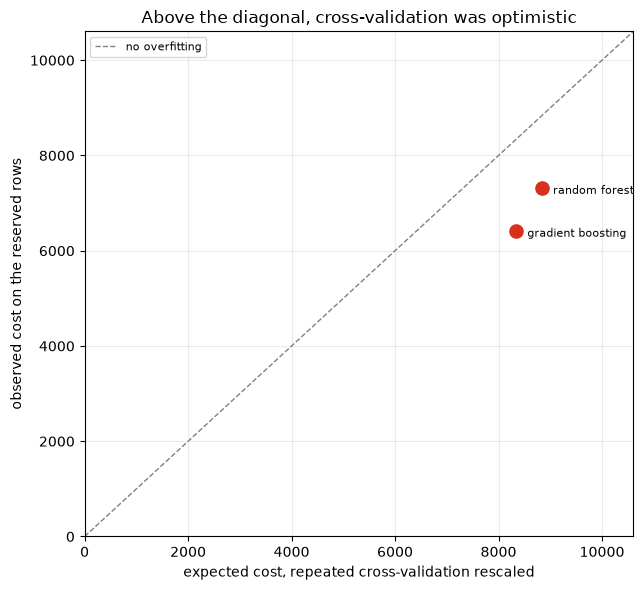

In [9]:
fig, ax = plt.subplots(figsize=(6.6, 6.0))

x, y = overfit["expected"], overfit["observed"]
limit = [0, max(x.max(), y.max()) * 1.2]

ax.plot(limit, limit, "--", color="grey", lw=1, label="no overfitting")
ax.scatter(x, y, s=90, color="#d7301f", zorder=3)
for name in overfit.index:
    ax.annotate(name, (overfit.loc[name, "expected"], overfit.loc[name, "observed"]),
                xytext=(8, -4), textcoords="offset points", fontsize=8)

ax.set_xlim(limit)
ax.set_ylim(limit)
ax.set_xlabel("expected cost, repeated cross-validation rescaled")
ax.set_ylabel("observed cost on the reserved rows")
ax.set_title("Above the diagonal, cross-validation was optimistic")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_overfitting.png", dpi=150)
plt.show()

In [10]:
# The rule declared in cell 2, applied without amendment
first, second = FINALISTS
gap = reserved.loc[first, "cost"] - reserved.loc[second, "cost"]

print("Applying the pre-registered arbitration rule\n")
print(f"criterion 1, cost on the reserved rows")
print(f"  {first:<22} {reserved.loc[first, 'cost']:>8,.0f}")
print(f"  {second:<22} {reserved.loc[second, 'cost']:>8,.0f}")
print(f"  gap : {abs(gap):,.0f} units")

if abs(gap) > 2000:
    selected = first if gap < 0 else second
    criterion = "cost on the reserved rows"
else:
    print("\n  the gap does not clear 2 000 units, criterion 1 does not decide")
    missed = {name: reserved.loc[name, "FN"] for name in FINALISTS}
    print(f"\ncriterion 2, missed failures")
    for name, value in missed.items():
        print(f"  {name:<22} {value:>8.0f}")
    if missed[first] != missed[second]:
        selected = min(missed, key=missed.get)
        criterion = "number of missed failures"
    else:
        print("\n  tie, moving to criterion 3")
        spread = {name: repeated[repeated["model"] == name]["cost"].std()
                  for name in FINALISTS}
        print(f"\ncriterion 3, dispersion on repeated cross-validation")
        for name, value in spread.items():
            print(f"  {name:<22} {value:>8,.0f}")
        selected = min(spread, key=spread.get)
        criterion = "stability across partitions"

print(f"\nselected model : {selected}")
print(f"deciding criterion : {criterion}")


Applying the pre-registered arbitration rule

criterion 1, cost on the reserved rows
  gradient boosting         6,410
  random forest             7,310
  gap : 900 units

  the gap does not clear 2 000 units, criterion 1 does not decide

criterion 2, missed failures
  gradient boosting             6
  random forest                 6

  tie, moving to criterion 3

criterion 3, dispersion on repeated cross-validation
  gradient boosting         1,203
  random forest             1,307

selected model : gradient boosting
deciding criterion : stability across partitions


In [11]:
import joblib

# Deliverable D5: all five fitted models are kept, not only the selected one
for name, entry in fitted.items():
    stem = name.replace(" ", "_")
    try:
        joblib.dump(entry["model"], MODELS_DIR / f"{stem}.joblib")
        print(f"{name:<22} saved as {stem}.joblib")
    except Exception as error:
        # The perceptron wraps a Keras model, which joblib may refuse
        entry["model"].network_.save(MODELS_DIR / f"{stem}.keras")
        print(f"{name:<22} saved as {stem}.keras ({type(error).__name__})")


gradient boosting      saved as gradient_boosting.joblib
random forest          saved as random_forest.joblib
perceptron             saved as perceptron.joblib
linear svm             saved as linear_svm.joblib
logistic regression    saved as logistic_regression.joblib


In [12]:
calibration = pd.read_csv(ROOT / "reports" / "calibration.csv", index_col=0)

manifest = {
    "model": selected,
    "threshold": float(fitted[selected]["threshold"]),
    "deciding_criterion": criterion,
    "fitted_on": "48 000 fitting rows",
    "columns": list(X_fit.columns),
    "repeated_cv_cost": float(repeated[repeated["model"] == selected]["cost"].mean()),
    "repeated_cv_std": float(repeated[repeated["model"] == selected]["cost"].std()),
    "reserved_cost": float(reserved.loc[selected, "cost"]),
    "reserved_recall": float(reserved.loc[selected, "recall"]),
    "reserved_missed": int(reserved.loc[selected, "FN"]),
    "reserved_false_alarms": int(reserved.loc[selected, "FP"]),
    "reserved_reference": int(reference),
    "brier": float(calibration.loc[selected, "brier"]),
    "mean_probability": float(calibration.loc[selected, "mean_probability"]),
    "actual_rate": float(calibration.loc[selected, "actual_rate"]),
}

with open(MODELS_DIR / "final_model.json", "w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2, ensure_ascii=False)

print(json.dumps({k: v for k, v in manifest.items() if k != "columns"},
                 indent=2, ensure_ascii=False))

{
  "model": "gradient boosting",
  "threshold": 0.0023719617165625095,
  "deciding_criterion": "stability across partitions",
  "fitted_on": "48 000 fitting rows",
  "repeated_cv_cost": 6674.666666666667,
  "repeated_cv_std": 1203.018426015717,
  "reserved_cost": 6410.0,
  "reserved_recall": 0.97,
  "reserved_missed": 6,
  "reserved_false_alarms": 341,
  "reserved_reference": 100000,
  "brier": 0.005174,
  "mean_probability": 0.016458,
  "actual_rate": 0.016667
}


In [13]:
reserved.to_csv(ROOT / "reports" / "arbitration.csv")
overfit.to_csv(ROOT / "reports" / "overfitting.csv")

print("two files written to reports/")
print("\nThe reserved rows will not be consulted again.")
print("The official test set stays closed.")

two files written to reports/

The reserved rows will not be consulted again.
The official test set stays closed.


## What comes out of this notebook

To be completed after execution, in four points.

The selected model and the criterion that decided.

The cost on the reserved rows, against the reference, and the detection rate
against the 90 % minimum set by the project brief.

The size of the measured overfitting, with the reservation that it superposes
two effects of opposite sign and is a lower bound.

Whether the ranking of the two finalists held between repeated cross-validation
and the reserved rows. A reversal would itself be a result, and would say that
138 units never separated anything.

The model is now frozen. No parameter, threshold or preparation step changes
before the official test set is opened.